In [3]:
import sklearn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
from sklearn import datasets

In [5]:
diab=datasets.load_diabetes()
print(diab.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [6]:
diab.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [7]:
X= diab.data
Y=diab.target

In [8]:
X.shape , Y.shape

((442, 10), (442,))

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X_train,X_test, Y_train,Y_test = train_test_split(X,Y,train_size=0.8,random_state=43) 

In [11]:
X_train.shape , Y_train.shape

((353, 10), (353,))

In [12]:
X_test.shape , Y_test.shape

((89, 10), (89,))

In [13]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [14]:
model = linear_model.LinearRegression()

In [15]:
model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -60.4 ,-226.08, 529.38,..., 226.29, 840.78, 34.71]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[1.78,1.08,0.96,...,0.56,0.24,0.08]"


In [16]:
Y_pred = model.predict(X_test)

In [17]:
print("r2_score is : %2f" %r2_score(Y_test,Y_pred))
print("MSE is : %2f" %mean_squared_error(Y_test,Y_pred))
print("RMSE is : %2f" %np.sqrt(mean_squared_error(Y_test,Y_pred)))
print("MAE is : %2f" %mean_absolute_error(Y_test,Y_pred))

r2_score is : 0.541984
MSE is : 2858.291506
RMSE is : 53.462992
MAE is : 44.582438


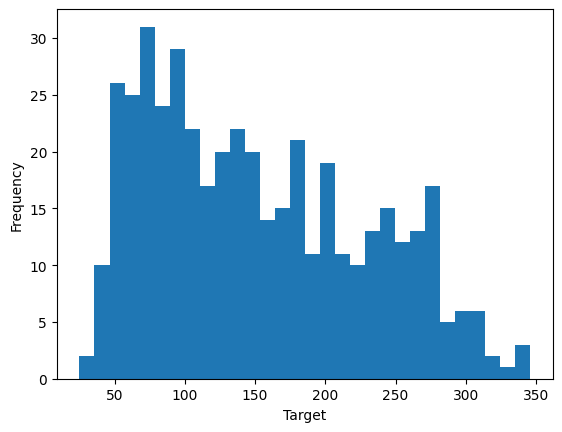

In [18]:
plt.hist(Y ,bins=30)
plt.xlabel("Target")
plt.ylabel("Frequency")
plt.show()

In [19]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [20]:
R = Ridge()
params = {'alpha' :[1e-15,1e-10,1e-8,1e-5,1e-2,1,5,10,20]}

grid = GridSearchCV(R , params , scoring='r2' ,cv=5)

In [21]:
model1 = grid.fit(X_train,Y_train)

In [22]:
Y_pred1 = model1.predict(X_test)

In [23]:
print("r2_score is : %2f" %r2_score(Y_test,Y_pred1))
print("MSE is : %2f" %mean_squared_error(Y_test,Y_pred1))
print("RMSE is : %2f" %np.sqrt(mean_squared_error(Y_test,Y_pred1)))
print("MAE is : %2f" %mean_absolute_error(Y_test,Y_pred1))

# did worse than linear as only mae reduced rest all increased

r2_score is : 0.541206
MSE is : 2863.144226
RMSE is : 53.508357
MAE is : 44.527557


In [24]:
grid.best_params_

{'alpha': 0.01}

In [25]:
grid.best_score_

np.float64(0.4657683792446258)

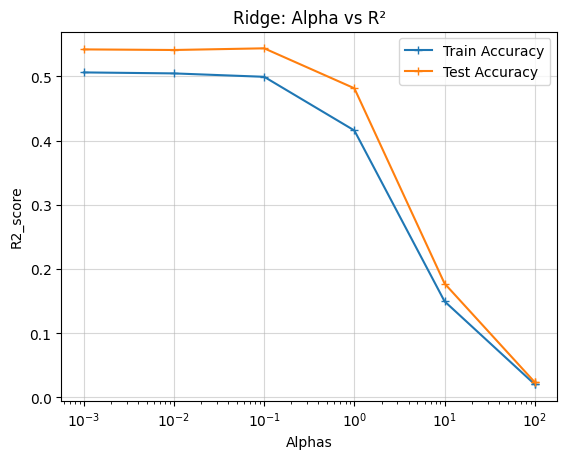

In [ ]:
alphas = [0.001,0.01,0.1,1,10,100,100]

train_acc = []
test_acc = []

for a in alphas:
    model=Ridge(alpha=a)
    model.fit(X_train , Y_train)

    train_acc.append(model.score(X_train , Y_train))
    test_acc.append(model.score(X_test , Y_test))

plt.plot(alphas, train_acc, marker='+', label="Train Accuracy")
plt.plot(alphas, test_acc, marker='+', label="Test Accuracy")

plt.xscale("log")
plt.title("Ridge: Alpha vs R²")
plt.xlabel("Alphas")
plt.ylabel("R2_score")

plt.legend()
plt.grid(alpha=0.5)
plt.show()

# as alpha = 0.0001 or 0.01 are give r2 = 0.5 hence we use em best alpha value

In [31]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [32]:
L=Lasso()
params = {'alpha' :[1e-15,1e-10,1e-8,1e-5,1e-2,1,5,10,20]}

grid1 = GridSearchCV(L , params , scoring='r2' ,cv=5)

In [33]:
model2=grid1.fit(X_train,Y_train)

c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.108501e+05, tolerance: 1.683e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.682722e+05, tolerance: 1.615e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale 

In [34]:
Y_pred2 = model2.predict(X_test)

In [35]:
print("r2_score is : %2f" %r2_score(Y_test,Y_pred2))
print("MSE is : %2f" %mean_squared_error(Y_test,Y_pred2))
print("RMSE is : %2f" %np.sqrt(mean_squared_error(Y_test,Y_pred2)))
print("MAE is : %2f" %mean_absolute_error(Y_test,Y_pred2))

# the og the best model above all

r2_score is : 0.539301
MSE is : 2875.030347
RMSE is : 53.619309
MAE is : 44.576726


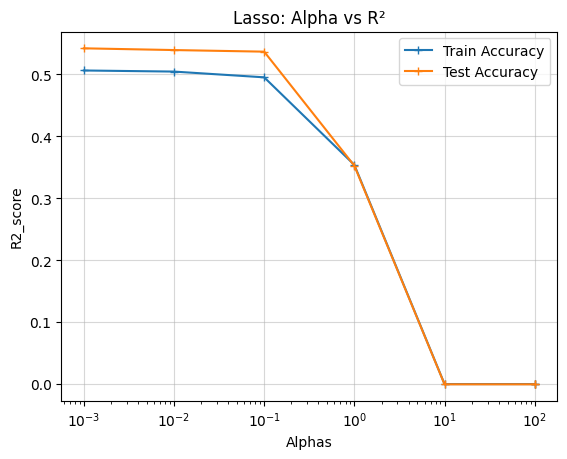

In [36]:
alphas = [0.001,0.01,0.1,1,10,100,100]

train_acc = []
test_acc = []

for a in alphas:
    model=Lasso(alpha=a)
    model.fit(X_train , Y_train)

    train_acc.append(model.score(X_train , Y_train))
    test_acc.append(model.score(X_test , Y_test))

plt.plot(alphas, train_acc, marker='+', label="Train Accuracy")
plt.plot(alphas, test_acc, marker='+', label="Test Accuracy")

plt.xscale("log")
plt.title("Lasso: Alpha vs R²")
plt.xlabel("Alphas")
plt.ylabel("R2_score")

plt.legend()
plt.grid(alpha=0.5)
plt.show()